# Trader Performance vs Market Sentiment

This notebook covers data loading, cleaning, merging, feature creation, charts, and insights.



In [3]:
# bring in all the libraries we need for this project
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

# dark background makes charts easier to read for financial data
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2e3250',
    'axes.labelcolor'  : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

# one color for each sentiment level
SENT_COLORS = {
    'Extreme Fear' : '#f78166',
    'Fear'         : '#ffa657',
    'Neutral'      : '#8b949e',
    'Greed'        : '#3fb950',
    'Extreme Greed': '#58a6ff',
}

# this is the correct order from most fearful to most greedy
SENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

print("Libraries loaded successfully")

Libraries loaded successfully


## Part A — Load and Inspect the Data

In [6]:
# load the fear greed index dataset
# this file has one row per day with a sentiment score and label
fear_greed = pd.read_csv(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\data\fear_greed_index.csv')

# load the trader data from hyperliquid
# this file has one row per trade with account, price, size, pnl, etc.
trader = pd.read_csv(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\notebooks\trader_sample.csv')

print("Fear Greed Index")
print(f"  Rows    : {fear_greed.shape[0]:,}")
print(f"  Columns : {fear_greed.shape[1]}")
print(f"  Columns : {fear_greed.columns.tolist()}")
print(f"  Missing : {fear_greed.isnull().sum().sum()}")
print(f"  Dupes   : {fear_greed.duplicated().sum()}")

print()
print("Trader Data")
print(f"  Rows    : {trader.shape[0]:,}")
print(f"  Columns : {trader.shape[1]}")
print(f"  Columns : {trader.columns.tolist()}")
print(f"  Missing : {trader.isnull().sum().sum()}")
print(f"  Dupes   : {trader.duplicated().sum()}")

Fear Greed Index
  Rows    : 2,644
  Columns : 4
  Columns : ['timestamp', 'value', 'classification', 'date']
  Missing : 0
  Dupes   : 0

Trader Data
  Rows    : 5,000
  Columns : 16
  Columns : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
  Missing : 0
  Dupes   : 0


In [7]:
# take a quick look at what the data actually looks like
print("Fear Greed - first 5 rows")
display(fear_greed.head())

print("Trader Data - first 5 rows")
display(trader.head())

Fear Greed - first 5 rows


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Trader Data - first 5 rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,MELANIA,0.76420,515.90,394.25,BUY,08-03-2025 20:36,-514.90,Short > Long,34.431363,0xe1d7303e2fc42a7cdae5041f2778750202ae00cdaad0...,78217687750,False,0.019712,4.550000e+14,1.740000e+12
1,0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,PURR/USDC,0.16183,99.00,16.02,SELL,28-10-2024 08:11,407428.35,Sell,2.660036,0x00000000000000000000000000000000000000000000...,43593087207,False,0.001602,3.290000e+14,1.730000e+12
2,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,17.53500,115.36,2022.84,SELL,05-03-2025 04:42,178757.55,Close Long,106.142736,0xf56d37a1433b9a919b96041eeb2cd901d200aa10e48b...,77214297554,True,0.606851,1.010000e+15,1.740000e+12
3,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,SUI,1.98310,1008.10,1999.16,BUY,06-04-2025 23:49,62314.60,Open Long,0.000000,0xc0946402f74b2419b6b3042108068f02060f00972334...,84298951614,True,0.599748,8.650000e+13,1.740000e+12
4,0x8477e447846c758f5a675856001ea72298fd9cb5,WLD,4.39210,4.00,17.57,SELL,10-06-2024 21:10,-1140.40,Open Short,0.000000,0xf93c774d772b2e0620c0040b23f5ee0172005f77aa76...,25553362653,True,0.006148,4.460000e+14,1.720000e+12


## Part A — Clean and Align Timestamps

In [ ]:
# the fear greed date column is already in YYYY-MM-DD format, just convert it
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

# the trader timestamp is in DD-MM-YYYY HH:MM format (IST timezone)
# we extract only the date part so we can merge on day level

trader['date'] = pd.to_datetime(    
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    dayfirst=True
         ).dt.normalize()  # normalize() sets time to 00:00:00, keeping only the date

# keep only the columns we need from the fear greed file before merging

fg_daily = fear_greed[['date', 'value', 'classification']].rename(columns={
    'value'          : 'fg_value',
    'classification' : 'sentiment'
})

# merge both datasets on date using an inner join
# inner join means we only keep dates that exist in both files
merged = trader.merge(fg_daily, on='date', how='inner')

print(f"Merged dataset : {len(merged):,} rows")
print(f"Merged dataset coloumns : {merged.columns}")
print(f"Date range     : {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Unique traders : {merged['Account'].nunique()}")
print(f"Unique dates   : {merged['date'].nunique()}")
print()
print("Sentiment distribution in merged data:")
print(merged['sentiment'].value_counts().to_string())

Merged dataset : 5,000 rows
Merged dataset coloumns : Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'fg_value', 'sentiment'],
      dtype='object')
Date range     : 2023-12-20 to 2025-05-01
Unique traders : 32
Unique dates   : 318

Sentiment distribution in merged data:
sentiment
Fear             1487
Greed            1175
Extreme Greed     916
Neutral           915
Extreme Fear      507


## Part A — Create Key Metrics

In [9]:
# create helper columns we will use throughout the analysis

# a trade is a win if it closed with positive pnl
merged['is_win'] = merged['Closed PnL'] > 0

# a trade is a long if the direction suggests buying or being long
merged['is_long'] = merged['Direction'].isin(['Open Long', 'Close Short', 'Long > Short'])

# group sentiment into 3 broad buckets for simpler comparisons
def broad_sentiment(s):
    if 'Fear' in s:  return 'Fear'
    if 'Greed' in s: return 'Greed'
    return 'Neutral'

merged['broad_sent'] = merged['sentiment'].apply(broad_sentiment)

# aggregate trades to daily level per account
# this gives us one row per trader per day with summary stats
daily = (
    merged
    .groupby(['Account', 'date', 'sentiment', 'broad_sent', 'fg_value'])
    .agg(
        daily_pnl    = ('Closed PnL', 'sum'),    # total pnl for that trader on that day
        trades_count = ('Trade ID',   'count'),  # how many trades they made
        win_trades   = ('is_win',     'sum'),    # how many of those were winners
        avg_size_usd = ('Size USD',   'mean'),   # average position size in dollars
        long_trades  = ('is_long',    'sum'),    # how many were long trades
    )
    .reset_index()
)

# win rate = winning trades divided by total trades
daily['win_rate']   = daily['win_trades']   / daily['trades_count']

# long ratio = long trades divided by total trades (0 = all short, 1 = all long)
daily['long_ratio'] = daily['long_trades']  / daily['trades_count']

print(f"Daily aggregated rows : {len(daily):,}")
print()
print("Sample of daily metrics:")
display(daily.head())

Daily aggregated rows : 1,211

Sample of daily metrics:


,Account,date,sentiment,broad_sent,fg_value,daily_pnl,trades_count,win_trades,avg_size_usd,long_trades,win_rate,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,Greed,76,0.000000,6,0,7543.866667,0,0.0,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,Greed,90,0.000000,1,0,35909.640000,0,0.0,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,Greed,94,-60.581858,1,0,965.340000,1,0.0,1.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,Greed,79,13.578257,1,1,1966.820000,1,1.0,1.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Extreme Greed,Greed,77,-5428.351794,3,0,15451.790000,3,0.0,1.0


In [10]:
# create a per-trader overall summary
# this tells us each trader's total performance across all days
trader_summary = (
    merged
    .groupby('Account')
    .agg(
        total_pnl    = ('Closed PnL', 'sum'),
        total_trades = ('Trade ID',   'count'),
        win_trades   = ('is_win',     'sum'),
        avg_size_usd = ('Size USD',   'mean'),
    )
    .reset_index()
)

trader_summary['win_rate'] = trader_summary['win_trades'] / trader_summary['total_trades']

# segment 1: high frequency vs low frequency traders
# traders above median trade count = high frequency
freq_median = trader_summary['total_trades'].median()
trader_summary['freq_segment'] = np.where(
    trader_summary['total_trades'] >= freq_median,
    'High Freq', 'Low Freq'
)

# segment 2: overall winners vs losers based on total pnl
trader_summary['perf_segment'] = np.where(
    trader_summary['total_pnl'] > 0,
    'Winners', 'Losers'
)

# segment 3: position size segments using 33rd and 66th percentile
q33 = trader_summary['avg_size_usd'].quantile(0.33)
q66 = trader_summary['avg_size_usd'].quantile(0.66)
trader_summary['size_segment'] = pd.cut(
    trader_summary['avg_size_usd'],
    bins   = [-np.inf, q33, q66, np.inf],
    labels = ['Small Size', 'Mid Size', 'Large Size']
)

print(f"Total traders analyzed : {len(trader_summary)}")
print()
print(f"Frequency segments : {trader_summary['freq_segment'].value_counts().to_dict()}")
print(f"Performance        : {trader_summary['perf_segment'].value_counts().to_dict()}")
print(f"Size segments      : {trader_summary['size_segment'].value_counts().to_dict()}")

Total traders analyzed : 32

Frequency segments : {'Low Freq': 16, 'High Freq': 16}
Performance        : {'Winners': 29, 'Losers': 3}
Size segments      : {'Small Size': 11, 'Large Size': 11, 'Mid Size': 10}



## Part B — Analysis and Charts

In [11]:
# calculate average pnl and win rate for each sentiment level
sent_perf = (
    daily
    .groupby('sentiment')
    .agg(
        avg_pnl      = ('daily_pnl',  'mean'),
        median_pnl   = ('daily_pnl',  'median'),
        avg_winrate  = ('win_rate',   'mean'),
        total_trades = ('trades_count','sum'),
    )
    .reindex([s for s in SENT_ORDER if s in daily['sentiment'].unique()])
    .reset_index()
)

print("Performance by Sentiment:")
print(sent_perf.to_string(index=False))

Performance by Sentiment:
    sentiment    avg_pnl  median_pnl  avg_winrate  total_trades
 Extreme Fear 500.633651    0.000000     0.302684           507
         Fear 207.341402    0.427180     0.372149          1487
      Neutral 136.185406    0.628924     0.382040           915
        Greed -86.179868    0.003709     0.356510          1175
Extreme Greed 174.822507    2.202527     0.398880           916


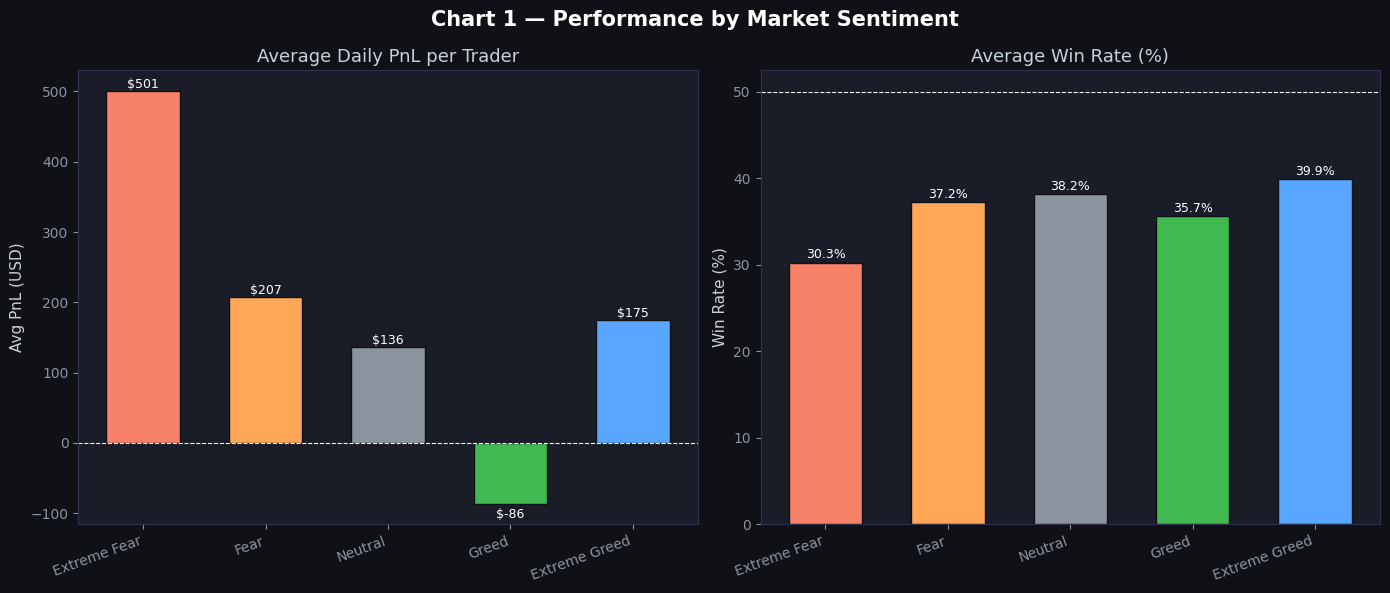

In [14]:
# CHART 1 — Average PnL and Win Rate by Sentiment
# this chart answers: does performance change based on fear vs greed?

labels      = sent_perf['sentiment'].tolist()
bar_colors  = [SENT_COLORS.get(s, '#8b949e') for s in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Chart 1 — Performance by Market Sentiment', fontsize=15, color='white', fontweight='bold')

# left chart: average daily pnl per trader
ax = axes[0]
bars = ax.bar(labels, sent_perf['avg_pnl'], color=bar_colors, edgecolor='#0f1117', width=0.6)
ax.set_title('Average Daily PnL per Trader')
ax.set_ylabel('Avg PnL (USD)')
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, sent_perf['avg_pnl']):
    offset = 4 if val >= 0 else -20
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
            f'${val:.0f}', ha='center', fontsize=9, color='white')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

# right chart: average win rate — dotted line at 50% to show break-even
ax = axes[1]
bars = ax.bar(labels, sent_perf['avg_winrate'] * 100, color=bar_colors, edgecolor='#0f1117', width=0.6)
ax.set_title('Average Win Rate (%)')
ax.set_ylabel('Win Rate (%)')
ax.axhline(50, color='white', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, sent_perf['avg_winrate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9, color='white')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputs\charts', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [15]:
# calculate behavior metrics per sentiment level
sent_beh = (
    daily
    .groupby('sentiment')
    .agg(
        avg_trades  = ('trades_count', 'mean'),  # how active traders are
        avg_size    = ('avg_size_usd',  'mean'),  # how big their positions are
        avg_long    = ('long_ratio',    'mean'),  # how bullish they are
    )
    .reindex([s for s in SENT_ORDER if s in daily['sentiment'].unique()])
    .reset_index()
)

print("Behavior by Sentiment:")
print(sent_beh.to_string(index=False))

Behavior by Sentiment:
    sentiment  avg_trades    avg_size  avg_long
 Extreme Fear    4.922330 6523.991676  0.471011
         Fear    4.519757 6648.581682  0.415753
      Neutral    4.399038 4181.574950  0.388848
        Greed    3.865132 7807.900467  0.375774
Extreme Greed    3.430712 4369.143961  0.349268


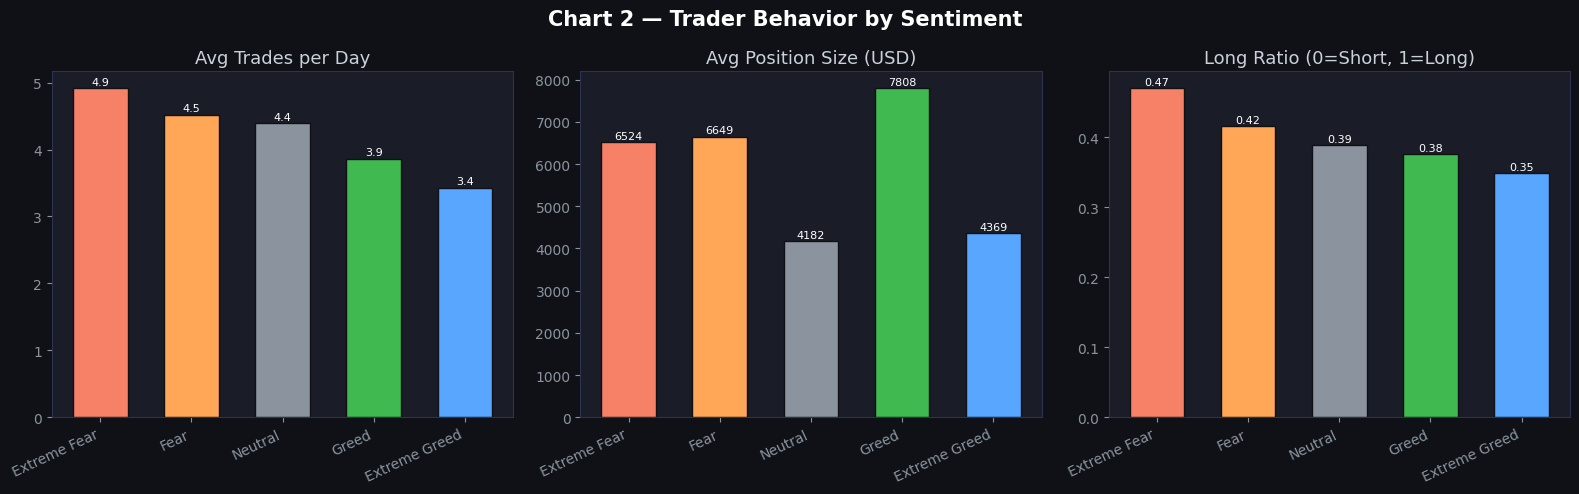

In [16]:
# CHART 2 — Trader Behavior by Sentiment
# this chart answers: do traders change HOW they trade based on sentiment?

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Chart 2 — Trader Behavior by Sentiment', fontsize=15, color='white', fontweight='bold')

metrics = [
    ('avg_trades', 'Avg Trades per Day',      '{:.1f}'),
    ('avg_size',   'Avg Position Size (USD)',  '{:.0f}'),
    ('avg_long',   'Long Ratio (0=Short, 1=Long)', '{:.2f}'),
]

for ax, (col, title, fmt) in zip(axes, metrics):
    vals = sent_beh[col]
    bars = ax.bar(sent_beh['sentiment'], vals, color=bar_colors, edgecolor='#0f1117', width=0.6)
    ax.set_title(title)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals) * 0.01,
                fmt.format(val), ha='center', fontsize=8, color='white')
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputschart2_behavior.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

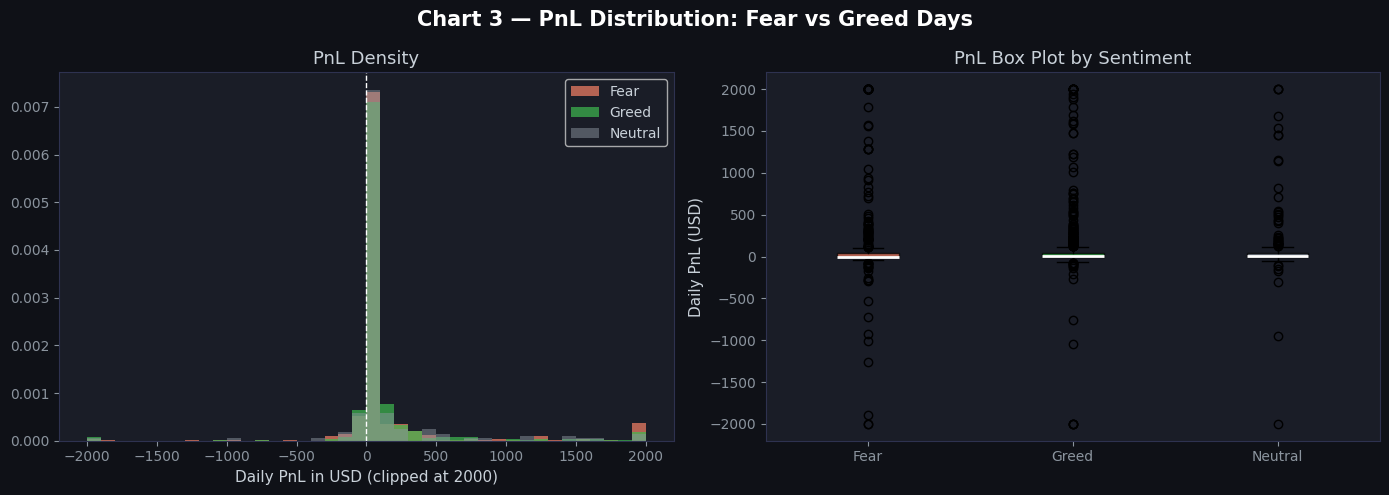

In [17]:
# CHART 3 — PnL Distribution on Fear vs Greed Days
# histogram shows where most daily pnl values fall
# boxplot shows median, spread, and outliers

# clip extreme values so the chart is readable (does not hide outliers, just scales them)
fear_pnl  = daily[daily['broad_sent'] == 'Fear']['daily_pnl'].clip(-2000, 2000)
greed_pnl = daily[daily['broad_sent'] == 'Greed']['daily_pnl'].clip(-2000, 2000)
neut_pnl  = daily[daily['broad_sent'] == 'Neutral']['daily_pnl'].clip(-2000, 2000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Chart 3 — PnL Distribution: Fear vs Greed Days', fontsize=15, color='white', fontweight='bold')

# left: density histogram — taller bar means more days had that pnl value
axes[0].hist(fear_pnl,  bins=40, alpha=0.7, color='#f78166', label='Fear',    density=True)
axes[0].hist(greed_pnl, bins=40, alpha=0.7, color='#3fb950', label='Greed',   density=True)
axes[0].hist(neut_pnl,  bins=40, alpha=0.5, color='#8b949e', label='Neutral', density=True)
axes[0].axvline(0, color='white', linestyle='--', linewidth=1)
axes[0].set_title('PnL Density')
axes[0].set_xlabel('Daily PnL in USD (clipped at 2000)')
axes[0].legend(facecolor='#1a1d27')

# right: boxplot — shows median line, box = 25th to 75th percentile, whiskers = range
bp = axes[1].boxplot(
    [fear_pnl.values, greed_pnl.values, neut_pnl.values],
    patch_artist=True,
    labels=['Fear', 'Greed', 'Neutral'],
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['#f78166', '#3fb950', '#8b949e']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('PnL Box Plot by Sentiment')
axes[1].set_ylabel('Daily PnL (USD)')

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputs/chart3_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

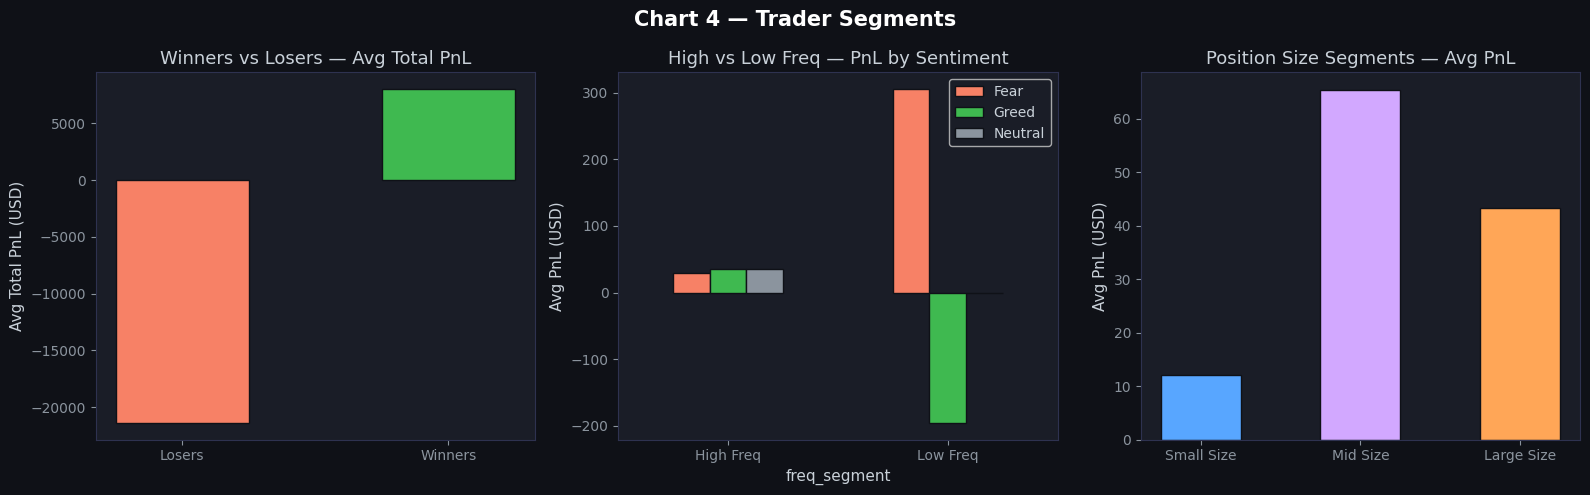

In [18]:
# CHART 4 — Trader Segments Analysis
# this shows how different types of traders perform

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Chart 4 — Trader Segments', fontsize=15, color='white', fontweight='bold')

# segment 1: average total pnl for winners vs losers
seg1 = trader_summary.groupby('perf_segment')['total_pnl'].mean()
axes[0].bar(seg1.index, seg1.values, color=['#f78166', '#3fb950'], edgecolor='#0f1117', width=0.5)
axes[0].set_title('Winners vs Losers — Avg Total PnL')
axes[0].set_ylabel('Avg Total PnL (USD)')

# segment 2: high freq vs low freq traders — pnl broken down by sentiment
merged_freq = merged.merge(trader_summary[['Account', 'freq_segment']], on='Account')
freq_pnl = merged_freq.groupby(['freq_segment', 'broad_sent'])['Closed PnL'].mean().unstack()
freq_pnl.plot(kind='bar', ax=axes[1],
              color=['#f78166', '#3fb950', '#8b949e'], edgecolor='#0f1117')
axes[1].set_title('High vs Low Freq — PnL by Sentiment')
axes[1].set_ylabel('Avg PnL (USD)')
axes[1].legend(facecolor='#1a1d27')
plt.setp(axes[1].get_xticklabels(), rotation=0)

# segment 3: small, mid, large position size traders — which size earns more?
merged_size = merged.merge(trader_summary[['Account', 'size_segment']], on='Account')
size_pnl = (merged_size.groupby('size_segment')['Closed PnL']
            .mean()
            .reindex(['Small Size', 'Mid Size', 'Large Size']))
axes[2].bar(size_pnl.index, size_pnl.values,
            color=['#58a6ff', '#d2a8ff', '#ffa657'], edgecolor='#0f1117', width=0.5)
axes[2].set_title('Position Size Segments — Avg PnL')
axes[2].set_ylabel('Avg PnL (USD)')

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputs/chart4_segments.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

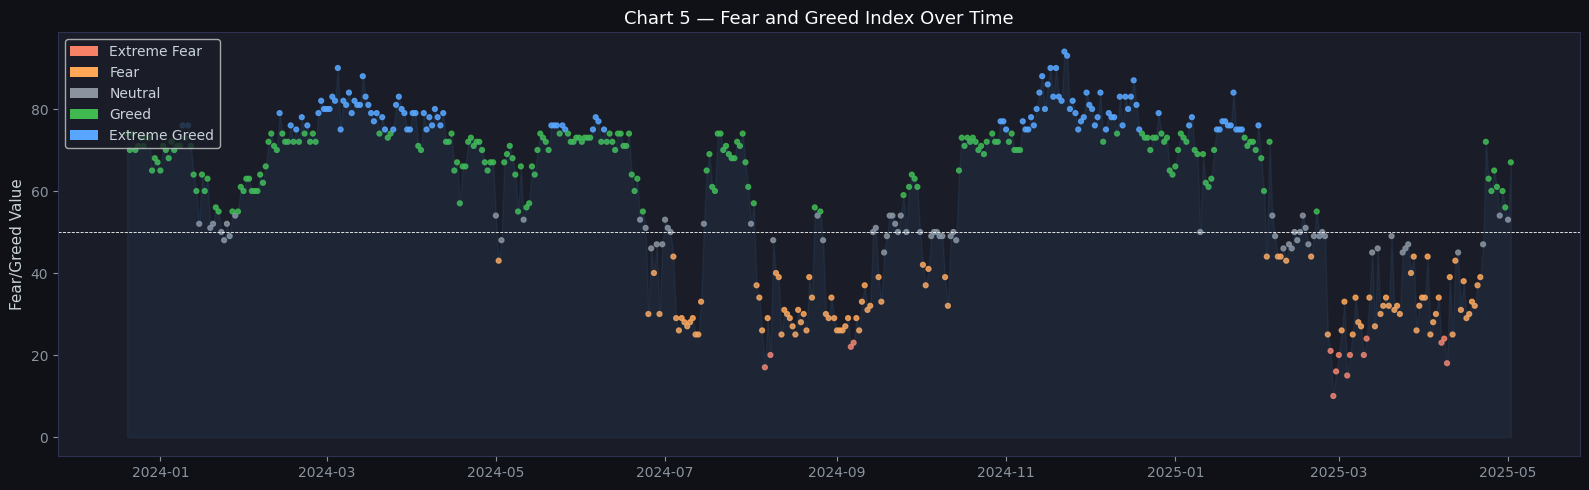

In [19]:
# CHART 5 — Fear and Greed Index Over Time
# this gives a visual timeline of the market mood during our analysis period

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# only show the date range that overlaps with trader data
fg_filtered = fear_greed[fear_greed['date'] >= merged['date'].min()].copy()

# color each day's dot based on its sentiment category
dot_colors = [SENT_COLORS.get(c, '#8b949e') for c in fg_filtered['classification']]
ax.scatter(fg_filtered['date'], fg_filtered['value'], c=dot_colors, s=12, alpha=0.85)
ax.fill_between(fg_filtered['date'], fg_filtered['value'], alpha=0.07, color='#58a6ff')

# horizontal line at 50 to show the fear/greed midpoint
ax.axhline(50, color='white', linewidth=0.6, linestyle='--')
ax.set_title('Chart 5 — Fear and Greed Index Over Time', color='white', fontsize=13)
ax.set_ylabel('Fear/Greed Value')

legend_handles = [mpatches.Patch(facecolor=c, label=s) for s, c in SENT_COLORS.items()]
ax.legend(handles=legend_handles, loc='upper left', facecolor='#1a1d27')

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputs/chart5_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()